**Cell 1: imports + download reference data**

In [1]:
import numpy as np, torch, scipy.io, matplotlib.pyplot as plt
!wget -q -nc https://raw.githubusercontent.com/maziarraissi/PINNs/master/appendix/Data/burgers_shock.mat

data = scipy.io.loadmat('burgers_shock.mat')
x_ref = data['x'].flatten()      # (256,)
t_ref = data['t'].flatten()      # (100,)
u_ref = data['usol']             # expected (256, 100): rows = x, cols = t
print(x_ref.shape, t_ref.shape, u_ref.shape)
print("x range:", x_ref.min(), x_ref.max(), "| t range:", t_ref.min(), t_ref.max())
print("u range:", u_ref.min(), u_ref.max())

(256,) (100,) (256, 100)
x range: -1.0 1.0 | t range: 0.0 0.99
u range: -0.9999810273487268 0.9999810273487268


**Cell 2: look at the truth first**

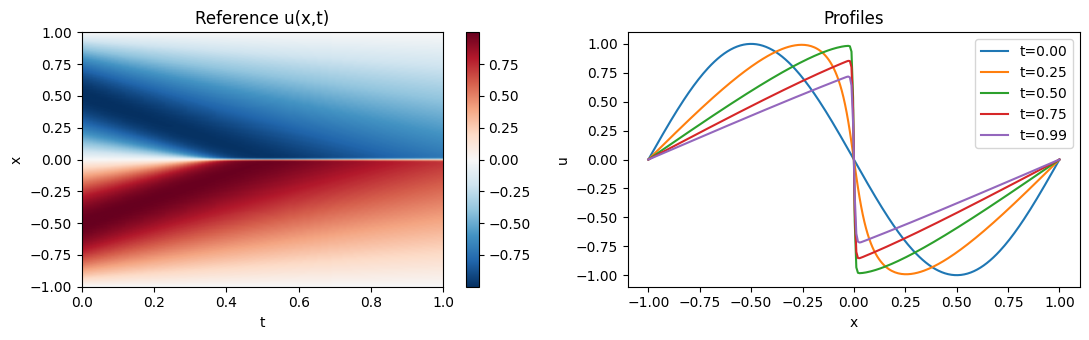

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
im = ax[0].imshow(u_ref, extent=[0, 1, -1, 1], origin='lower', aspect='auto', cmap='RdBu_r')
ax[0].set(xlabel='t', ylabel='x', title='Reference u(x,t)'); plt.colorbar(im, ax=ax[0])
for tt in [0.0, 0.25, 0.5, 0.75, 1.0]:
    k = np.argmin(abs(t_ref - tt)); ax[1].plot(x_ref, u_ref[:, k], label=f't={t_ref[k]:.2f}')
ax[1].set(xlabel='x', ylabel='u', title='Profiles'); ax[1].legend()
plt.tight_layout(); plt.show()

**Cell 3: setup, network, derivatives**

In [3]:
import torch.nn as nn
torch.manual_seed(0)
dev = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device:", dev)
NU = 0.01/np.pi

class PINN(nn.Module):
    def __init__(self, hidden=20, layers=8):
        super().__init__()
        dims = [2] + [hidden]*layers + [1]
        self.lin = nn.ModuleList([nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)])
        for l in self.lin: nn.init.xavier_normal_(l.weight); nn.init.zeros_(l.bias)  # Xavier suits tanh
    def forward(self, x, t):
        h = torch.cat([x, t], dim=1)          # (N,2)
        for l in self.lin[:-1]: h = torch.tanh(l(h))
        return self.lin[-1](h)                # (N,1), no activation on output

def derivs(model, x, t):
    """returns u, u_t, u_x, u_xx via autograd (x, t need requires_grad=True)"""
    u = model(x, t)
    g = lambda f, v: torch.autograd.grad(f, v, torch.ones_like(f), create_graph=True)[0]
    u_x, u_t = g(u, x), g(u, t)
    u_xx = g(u_x, x)
    return u, u_t, u_x, u_xx

model = PINN().to(dev)
print("params:", sum(p.numel() for p in model.parameters()))

device: cpu
params: 3021


**Cell 4: sample training points (drawn once, fixed)**

In [4]:
def pts(n, xlo, xhi, tlo, thi):
    x = (xlo + (xhi-xlo)*torch.rand(n,1)).to(dev)
    t = (tlo + (thi-tlo)*torch.rand(n,1)).to(dev)
    return x, t

N_PDE, N_IC, N_BC = 10000, 200, 200
x_f, t_f = pts(N_PDE, -1, 1, 0, 1)                    # interior
x_f.requires_grad_(True); t_f.requires_grad_(True)
x_i, _ = pts(N_IC, -1, 1, 0, 0); t_i = torch.zeros_like(x_i)   # t=0
u_i = -torch.sin(np.pi*x_i)                            # IC target
t_b = torch.rand(N_BC,1).to(dev)                       # walls
x_b = torch.cat([-torch.ones(N_BC,1), torch.ones(N_BC,1)]).to(dev)
t_b = torch.cat([t_b, t_b])

# sanity check: residual of the reference-like IC and untrained net
u,u_t,u_x,u_xx = derivs(model, x_f, t_f)
res = u_t + u*u_x - NU*u_xx
print("untrained residual mean sq:", (res**2).mean().item())
print("IC targets range:", u_i.min().item(), u_i.max().item())

untrained residual mean sq: 0.0034737060777843
IC targets range: -0.9999891519546509 0.999988317489624


**Cell 5: loss, validation metric, Adam training**

In [5]:
W_PDE, W_IC, W_BC = 1, 20, 20     # start with Project 2's weights

def losses(model):
    u, u_t, u_x, u_xx = derivs(model, x_f, t_f)
    l_pde = ((u_t + u*u_x - NU*u_xx)**2).mean()      # PDE residual
    l_ic  = ((model(x_i, t_i) - u_i)**2).mean()      # initial condition
    l_bc  = (model(x_b, t_b)**2).mean()              # u = 0 at walls
    return l_pde, l_ic, l_bc

# reference grid as tensors (rows = x, cols = t, matches u_ref)
X, T = np.meshgrid(x_ref, t_ref, indexing='ij')
xr = torch.tensor(X.reshape(-1,1), dtype=torch.float32, device=dev)
tr = torch.tensor(T.reshape(-1,1), dtype=torch.float32, device=dev)
def rel_l2(model):
    with torch.no_grad(): up = model(xr, tr).cpu().numpy().reshape(u_ref.shape)
    return np.linalg.norm(up - u_ref) / np.linalg.norm(u_ref)

torch.manual_seed(0); model = PINN().to(dev)         # fresh model each run
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9997)
hist = []                                            # (pde, ic, bc, rel_l2)

for it in range(10001):
    opt.zero_grad()
    lp, li, lb = losses(model)
    loss = W_PDE*lp + W_IC*li + W_BC*lb
    loss.backward(); opt.step(); sched.step()
    if it % 100 == 0: hist.append((lp.item(), li.item(), lb.item(), rel_l2(model)))
    if it % 1000 == 0:
        print(f"{it:5d} pde {lp.item():.2e} ic {li.item():.2e} bc {lb.item():.2e} relL2 {hist[-1][3]:.3f}")

    0 pde 3.47e-03 ic 4.31e-01 bc 6.67e-03 relL2 0.921
 1000 pde 2.61e-01 ic 1.56e-03 bc 6.18e-05 relL2 0.402
 2000 pde 1.94e-01 ic 9.52e-04 bc 2.45e-05 relL2 0.305
 3000 pde 2.36e-02 ic 1.36e-04 bc 3.18e-05 relL2 0.180
 4000 pde 6.19e-03 ic 3.10e-05 bc 9.70e-06 relL2 0.165
 5000 pde 3.81e-03 ic 2.03e-05 bc 3.51e-06 relL2 0.162
 6000 pde 2.79e-03 ic 1.52e-05 bc 1.85e-06 relL2 0.155
 7000 pde 2.08e-03 ic 1.31e-05 bc 1.12e-06 relL2 0.135
 8000 pde 1.29e-03 ic 6.73e-06 bc 7.32e-07 relL2 0.078
 9000 pde 1.09e-03 ic 6.09e-06 bc 5.44e-07 relL2 0.076
10000 pde 9.61e-04 ic 5.52e-06 bc 4.19e-07 relL2 0.075


**Cell 6: diagnostics: loss curves, profiles, error map**

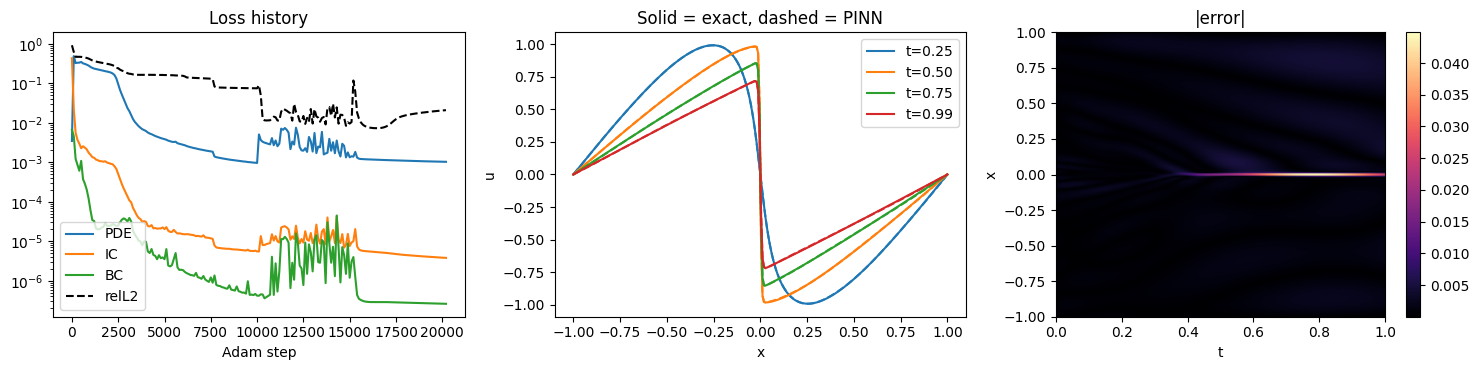

max abs err: 0.0448420821018356


In [11]:
h = np.array(hist); its = np.arange(len(h))*100
with torch.no_grad(): up = model(xr, tr).cpu().numpy().reshape(u_ref.shape)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].semilogy(its, h[:,0], label='PDE'); ax[0].semilogy(its, h[:,1], label='IC')
ax[0].semilogy(its, h[:,2], label='BC'); ax[0].semilogy(its, h[:,3], 'k--', label='relL2')
ax[0].set(xlabel='Adam step', title='Loss history'); ax[0].legend()

for tt, c in zip([0.25, 0.5, 0.75, 0.99], ['C0','C1','C2','C3']):
    k = np.argmin(abs(t_ref - tt))
    ax[1].plot(x_ref, u_ref[:,k], c, label=f't={t_ref[k]:.2f}')
    ax[1].plot(x_ref, up[:,k], c+'--')
ax[1].set(xlabel='x', ylabel='u', title='Solid = exact, dashed = PINN'); ax[1].legend()

im = ax[2].imshow(abs(up-u_ref), extent=[0,1,-1,1], origin='lower', aspect='auto', cmap='magma')
ax[2].set(xlabel='t', ylabel='x', title='|error|'); plt.colorbar(im, ax=ax[2])
plt.tight_layout(); plt.show()
print("max abs err:", abs(up-u_ref).max())

**Cell 7: error away from shock + L-BFGS (continues from current Adam model)**

In [7]:
mask = abs(x_ref) > 0.05                       # exclude the shock band
def err_off_shock(model):
    with torch.no_grad(): up = model(xr, tr).cpu().numpy().reshape(u_ref.shape)
    return np.linalg.norm((up-u_ref)[mask]) / np.linalg.norm(u_ref[mask])
print("before L-BFGS: relL2", rel_l2(model), "| off-shock relL2", err_off_shock(model))

opt2 = torch.optim.LBFGS(model.parameters(), max_iter=1000, history_size=50,
                         line_search_fn='strong_wolfe', tolerance_grad=1e-10, tolerance_change=1e-14)
hist_lb = []                                   # one entry per closure call
def closure():
    opt2.zero_grad()
    lp, li, lb = losses(model)
    loss = W_PDE*lp + W_IC*li + W_BC*lb
    loss.backward()
    hist_lb.append((lp.item(), li.item(), lb.item()))
    return loss
opt2.step(closure)                              # runs up to max_iter iterations

print("closure calls:", len(hist_lb), "| final pde/ic/bc:", hist_lb[-1])
print("after L-BFGS: relL2", rel_l2(model), "| off-shock relL2", err_off_shock(model))

before L-BFGS: relL2 0.07483196502124005 | off-shock relL2 0.007878113203330267
closure calls: 18 | final pde/ic/bc: (0.0009606047533452511, 5.523389518202748e-06, 4.173955687747366e-07)
after L-BFGS: relL2 0.07483525873645033 | off-shock relL2 0.00787656525073674


**Cell 8: RAR, then continue Adam from the current model**

In [8]:
import copy
model_adam = copy.deepcopy(model)            # backup of the current result

def add_hard_points(n_cand=50000, n_add=5000, chunk=10000):
    xc, tc = pts(n_cand, -1, 1, 0, 1)        # random candidates
    r = []
    for i in range(0, n_cand, chunk):        # chunks keep memory low
        xi = xc[i:i+chunk].clone().requires_grad_(True)
        ti = tc[i:i+chunk].clone().requires_grad_(True)
        u, u_t, u_x, u_xx = derivs(model, xi, ti)
        r.append((u_t + u*u_x - NU*u_xx).abs().detach())
    idx = torch.cat(r).flatten().topk(n_add).indices   # worst residuals
    return xc[idx], tc[idx]

xn, tn = add_hard_points()
print("mean |x| of new points:", xn.abs().mean().item(), "(uniform would be 0.5)")
x_f = torch.cat([x_f.detach(), xn]).requires_grad_(True)   # losses() reads these globals
t_f = torch.cat([t_f.detach(), tn]).requires_grad_(True)
print("PDE points now:", x_f.shape[0])

opt = torch.optim.Adam(model.parameters(), lr=5e-4)        # lower lr for fine-tuning
for it in range(5001):
    opt.zero_grad()
    lp, li, lb = losses(model)
    loss = W_PDE*lp + W_IC*li + W_BC*lb
    loss.backward(); opt.step()
    if it % 100 == 0: hist.append((lp.item(), li.item(), lb.item(), rel_l2(model)))
    if it % 1000 == 0:
        print(f"{it:5d} pde {lp.item():.2e} ic {li.item():.2e} bc {lb.item():.2e} "
              f"relL2 {hist[-1][3]:.3f} off-shock {err_off_shock(model):.4f}")

mean |x| of new points: 0.17857883870601654 (uniform would be 0.5)
PDE points now: 15000
    0 pde 5.08e-03 ic 5.52e-06 bc 4.17e-07 relL2 0.090 off-shock 0.0711
 1000 pde 2.55e-03 ic 9.92e-06 bc 5.32e-07 relL2 0.011 off-shock 0.0077
 2000 pde 7.54e-03 ic 2.47e-05 bc 1.58e-05 relL2 0.019 off-shock 0.0093
 3000 pde 5.52e-03 ic 1.12e-05 bc 1.11e-05 relL2 0.022 off-shock 0.0079
 4000 pde 3.22e-03 ic 1.93e-05 bc 7.24e-06 relL2 0.030 off-shock 0.0082
 5000 pde 1.42e-03 ic 9.28e-06 bc 3.05e-06 relL2 0.010 off-shock 0.0068


**Cell 9: decayed fine-tuning from the current model, then L-BFGS**

In [9]:
model_rar = copy.deepcopy(model)                       # backup of Cell 8 result
opt = torch.optim.Adam(model.parameters(), lr=5e-4)
sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9994)   # 5e-4 -> ~2.5e-5 over 5000 steps
for it in range(5001):
    opt.zero_grad()
    lp, li, lb = losses(model)
    loss = W_PDE*lp + W_IC*li + W_BC*lb
    loss.backward(); opt.step(); sched.step()
    if it % 100 == 0: hist.append((lp.item(), li.item(), lb.item(), rel_l2(model)))
    if it % 1000 == 0:
        print(f"{it:5d} lr {sched.get_last_lr()[0]:.1e} pde {lp.item():.2e} relL2 {hist[-1][3]:.4f} off-shock {err_off_shock(model):.4f}")

# L-BFGS polish (now that the shock band is well sampled)
opt2 = torch.optim.LBFGS(model.parameters(), max_iter=1000, history_size=50,
                         line_search_fn='strong_wolfe', tolerance_grad=1e-10, tolerance_change=1e-14)
hist_lb = []
opt2.step(closure)                                     # closure from Cell 7 (reads current x_f, t_f)
print("L-BFGS closure calls:", len(hist_lb), "| relL2", rel_l2(model), "| off-shock", err_off_shock(model))

    0 lr 5.0e-04 pde 1.39e-03 relL2 0.1179 off-shock 0.1151
 1000 lr 2.7e-04 pde 1.17e-03 relL2 0.0074 off-shock 0.0057
 2000 lr 1.5e-04 pde 1.13e-03 relL2 0.0095 off-shock 0.0055
 3000 lr 8.3e-05 pde 1.09e-03 relL2 0.0161 off-shock 0.0055
 4000 lr 4.5e-05 pde 1.06e-03 relL2 0.0188 off-shock 0.0054
 5000 lr 2.5e-05 pde 1.03e-03 relL2 0.0209 off-shock 0.0054
L-BFGS closure calls: 1083 | relL2 0.004467513652743274 | off-shock 0.002548912066381318


**Cell 10: save final weights**

In [10]:
torch.save(model.state_dict(), 'pinn_burgers_final.pt')
print("saved | relL2:", rel_l2(model))

saved | relL2: 0.004467513652743274


**Cell 11: side-by-side heatmaps saved as a figure**

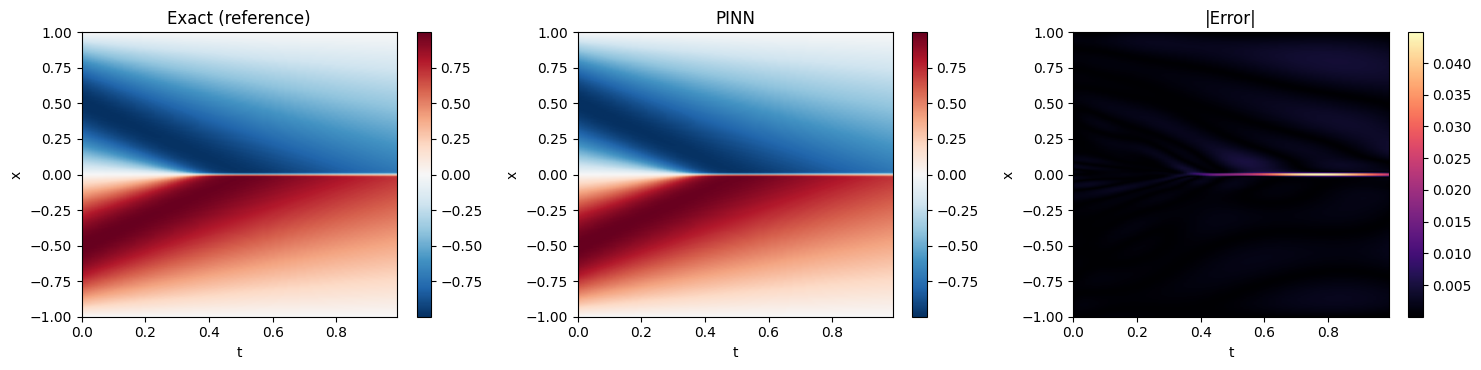

final relL2: 0.004467513652743274 | max abs err: 0.0448420821018356


In [12]:
import os; os.makedirs('figures', exist_ok=True)
with torch.no_grad(): up = model(xr, tr).cpu().numpy().reshape(u_ref.shape)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
for a, f, ttl, cm in zip(ax, [u_ref, up, abs(up-u_ref)],
                         ['Exact (reference)', 'PINN', '|Error|'], ['RdBu_r','RdBu_r','magma']):
    im = a.imshow(f, extent=[0,0.99,-1,1], origin='lower', aspect='auto', cmap=cm)
    a.set(xlabel='t', ylabel='x', title=ttl); plt.colorbar(im, ax=a)
plt.tight_layout(); plt.savefig('figures/burgers_heatmaps.png', dpi=150); plt.show()
print("final relL2:", rel_l2(model), "| max abs err:", abs(up-u_ref).max())

**Cell 12: animated shock GIF (every 2nd time step, exact vs PINN)**

In [17]:
from matplotlib.animation import FuncAnimation, PillowWriter
fig, ax = plt.subplots(figsize=(6, 3.6))
l1, = ax.plot(x_ref, u_ref[:,0], 'k-', label='Exact')
l2, = ax.plot(x_ref, up[:,0], 'r--', label='PINN')
ax.set(xlim=(-1,1), ylim=(-1.1,1.1), xlabel='x', ylabel='u'); ax.legend(loc='upper right')
title = ax.set_title('t = 0.00')
def update(k):
    l1.set_ydata(u_ref[:,k]); l2.set_ydata(up[:,k]); title.set_text(f'Burgers shock: t = {t_ref[k]:.2f}')
    return l1, l2, title
FuncAnimation(fig, update, frames=range(0, 100, 2)).save('figures/burgers_shock.gif', writer=PillowWriter(fps=12))
plt.close(); print("saved figures/burgers_shock.gif")

saved figures/burgers_shock.gif


**Cell 13: play the GIF inline**

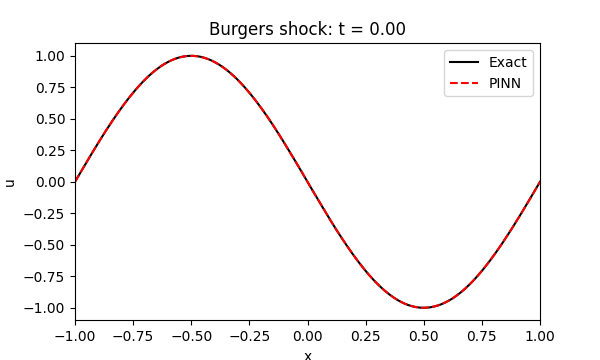

In [18]:
from IPython.display import Image, display
display(Image('figures/burgers_shock.gif'))